<h1><center>Laboratorio 4: EDA en Pandas 🐼</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>


### Cuerpo Docente:

- Profesores: Pablo Badilla, Diego Cortez
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes


### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Álvaro Sifuentes Tasayco
- Nombre de alumno 2: Sebastián Morales Castillo


### **Link de repositorio de GitHub:** `https://github.com/cadaeic628/MDS7202`


## Reglas:

- **Grupos de 2 personas**
- Asistencia **obligatoria** a instrucciones del lab (viernes 16.15). Luego, pueden quedarse trabajando en las salas o irse.
- **No se revisarán entregas de personas ausentes**.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibidas las copias.
- Pueden usar cualquer matrial del curso que estimen conveniente.

### Objetivos principales del laboratorio

- Aplicar los paradigmas y buenas prácticas de programación vistas hasta este momento.
- Utilizar las funciones de la librería `pandas` para realizar análisis exploratorio de datos
- Aplicar principios de visualización de datos vistos en clases para mostrar patrones en los datos

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas de `pandas`.


## Descripción del laboratorio.


### Importamos librerias utiles 😸


In [2]:
# Libreria Core del lab.

# Libreria para plotear
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import Markdown, display
from scipy import stats

# Segmentación de Clientes en Tienda de Retail 🛍️


<p align="center">
  <img width=300 src="https://s1.eestatic.com/2018/04/14/social/la_jungla_-_social_299733421_73842361_854x640.jpg">
</p>


## 1.1 Cargar dataset [0.5 puntos]


Mr. Lepin Mora quien es el gerente de una cotizada tienda de retail en Europa, les solicita si pueden analizar los datos de algunas de sus tiendas.

Para esto, el área de ventas les entrega el 2 archivos: `online_retail_II.pickle` y `online_retail_I.pickle`.

- Cargue ambas fuentes y asegúrese que las columnas son del tipo correcto como en el ejemplo de df_retail_1 visualizando los datos para determinar el tipo. Para fechas, puede usar `'datetime64[ns]'`
- Combine los dataframes en uno solo. ¿Qué función debe utilizar en este caso?
- Señale las columnas que componen el dataset combinado, el tipo de variable presente en cada columna y comente que representa cada una de estas.

**Respuesta:**


In [3]:
df_retail_1 = pd.read_pickle("online_retail_I.pickle")
df_retail_1 = df_retail_1.astype(
    {
        "Invoice": "category",
        "StockCode": "category",
        "Description": str,
        "Customer ID": "category",
    }
)
df_retail_1.head()

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom


In [4]:
df_retail_2 = pd.read_pickle("online_retail_II.pickle")
print("Retail 2:", df_retail_2.shape)

Retail 2: (28816, 2)


In [5]:
df_retail_2 = df_retail_2.astype({"Invoice": "category"})

df_retail_2["InvoiceDate"] = pd.to_datetime(df_retail_2["InvoiceDate"])
df_retail_2.head()

,Invoice,InvoiceDate
0,489434,2009-12-01 07:45:00
1,489435,2009-12-01 07:46:00
2,489436,2009-12-01 09:06:00
3,489437,2009-12-01 09:08:00
4,489438,2009-12-01 09:24:00


In [6]:
df_retail = pd.merge(df_retail_1, df_retail_2, on="Invoice", how="left")
print(df_retail.dtypes)
df_retail.head()

Invoice              category
StockCode            category
Description               str
Quantity                int64
Price                 float64
Customer ID          category
Country                object
InvoiceDate    datetime64[ns]
dtype: object


,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,InvoiceDate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,13085.0,United Kingdom,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,13085.0,United Kingdom,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,13085.0,United Kingdom,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,13085.0,United Kingdom,2009-12-01 07:45:00


**1. Función de cruce utilizada:**
Para combinar los conjuntos de datos, se utilizó la función `pd.merge()` de Pandas, aplicando un parámetro `how="left"`. Se seleccionó este tipo de cruce (Left Join) porque nuestro objetivo principal es conservar el 100% de los registros de las transacciones (el dataframe principal o izquierdo), añadiendo la información complementaria del segundo dataframe (como datos del cliente o descripciones) sin perder ventas históricas en caso de que existan valores nulos o sin correspondencia en la tabla secundaria.

**2. Diccionario de variables del dataset combinado:**
Tras el cruce, el dataset final se compone de las siguientes columnas:

* **Invoice / InvoiceNo:** Variable categórica nominal (String). Representa el número de factura o identificador único de la transacción. (Si empieza con 'C', indica una cancelación).
* **StockCode:** Variable categórica nominal (String). Corresponde al código único que identifica a cada artículo o producto en el inventario.
* **Description:** Variable de texto (String). Es el nombre o la descripción textual del producto vendido.
* **Quantity:** Variable numérica discreta (Integer). Indica la cantidad de unidades del producto que fueron compradas (o devueltas, si es negativa) en esa transacción en particular.
* **InvoiceDate:** Variable temporal (Datetime). Señala la fecha y hora exacta en la que se generó la factura.
* **Price / UnitPrice:** Variable numérica continua (Float). Representa el precio unitario del producto en libras esterlinas (o la moneda local del dataset).
* **Customer ID:** Variable categórica nominal (Float/String). Es el identificador único asignado a cada cliente que realizó la compra.
* **Country:** Variable categórica nominal (String). Indica el país de residencia del cliente o el país donde se originó la orden de compra.

## 1.2 Analisís Explotatorio de los Datos [0.5 puntos]

En base a la primera visualización del dataset, _Don Mora_ le solicita que realicen un análisis exploratorio de los datos, para esto les deberán realizar un análisis univariado y multivariado. De la revisión, ustedes deben explicar potenciales anomalías visualizadas y señalar si existe la necesidad de realizar una limpieza de datos.

Explique a que nos referimos con análisis univariable, multivariable y de datos faltantes. ¿Qué beneficios nos otorga estudiar estos datos?. Sea conciso con su respuesta y no escriba mas de 5 líneas para su respuesta.

**Respuesta a la Pregunta:**


> El análisis univariado consiste en estudiar cada variable de forma individual (por ejemplo: Quantity o Price), mientras que el multivariado analiza relaciones entre variables, como precio y cantidad o cliente y país. Los datos faltantes corresponden a valores ausentes, como ocurre en Customer ID. El EDA nos permite detectar anomalías como cantidades negativas o precios atípicos. Estos análisis ayudan a comprender la calidad de los datos y determinar si es necesaria una limpieza previa al análisis.


### 1.2.1 Análisis Univariado [1.5 Puntos]

A continuación, se le presentan dos funciones para analizar los datos que componen un dataframe. La primera de estas es la función `profile_serie()` la cual recibe una serie y le entrega un análisis detallado de los datos que conforman dicha serie.

Ejecute la funcion `profile_serie()` sobre cada serie para realizar un análisis univariado de estas. A continuación, comente acerca de el comportamiento de cada variable según las estadísticas descriptivas y los gráficos generados.


In [7]:
from pandas.api.types import is_datetime64_any_dtype, is_numeric_dtype, is_timedelta64_dtype


def profile_serie(serie_in, n_samples=1000, random_state=42):
    serie = serie_in.copy()

    profile = pd.Series(dtype="object")
    profile["Type"] = serie.dtype
    profile = pd.concat([profile, serie.describe()])

    # profile = pd.Series([])

    if is_numeric_dtype(serie):
        profile["Negative"] = (serie < 0).sum()
        profile["Negative (%)"] = str(round((serie < 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Zeros"] = (serie == 0).sum()
        profile["Zeros (%)"] = str(round((serie == 0).sum() / len(serie) * 100, 2)) + " %"
        profile["Kurt"] = serie.kurt()
        profile["Skew"] = serie.skew()

    profile[" "] = " "  # espacio

    profile["Missing cells"] = serie.isnull().sum()
    profile["Missing cells (%)"] = str(round(serie.isnull().sum() / len(serie) * 100, 2)) + " %"
    profile["Duplicate rows"] = serie.duplicated(False).sum()
    profile["Duplicate rows (%)"] = str(round(serie.duplicated(False).sum() / len(serie) * 100, 2)) + " %"
    profile["Total size in memory"] = str(serie.memory_usage(index=True)) + " bytes"

    # profile = pd.concat([profile, description])

    profile = profile.rename(
        index={
            "count": "Number of observations",
            "mean": "Mean",
            "std": "Std",
            "min": "Min",
            "max": "Max",
            "unique": "Unique",
            "top": "Top",
            "freq": "Freq",
        }
    )
    no_outliers_fig = None

    if is_numeric_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name} - With Outliers")

        no_outliers = sampled_serie.loc[(np.abs(stats.zscore(sampled_serie)) < 3)]
        # zscore = https://es.wikipedia.org/wiki/Unidad_tipificada

        no_outliers_fig = px.histogram(no_outliers, marginal="box", title=f"{serie.name} - Without Outliers")

    elif is_datetime64_any_dtype(serie) or is_timedelta64_dtype(serie):
        sampled_serie = serie.sample(n_samples, random_state=random_state)
        fig = px.histogram(sampled_serie, marginal="box", title=f"{serie.name}")

    else:
        count = serie.value_counts()[0:100].reset_index().rename(columns={"count": "Count"})
        fig = px.bar(
            x=count[serie.name].astype(str),
            y=count["Count"],
            title=f"100 Most common categories of {serie.name}",
        )
    display(Markdown(f"## {serie.name} Profile"))
    display(profile)
    fig.show()

    if no_outliers_fig:
        no_outliers_fig.show()

    # return fig, profile

In [8]:
for col in df_retail.columns:
    profile_serie(df_retail[col])

## Invoice Profile

Type                           category
Number of observations           525461
Unique                            28816
Top                              537434
Freq                                675
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   517456
Duplicate rows (%)              98.48 %
Total size in memory      2338390 bytes
dtype: object

## StockCode Profile

Type                           category
Number of observations           525461
Unique                             4632
Top                              85123A
Freq                               3516
                                       
Missing cells                         0
Missing cells (%)                 0.0 %
Duplicate rows                   525026
Duplicate rows (%)              99.92 %
Total size in memory      1220246 bytes
dtype: object

## Description Profile

...

Type                           category
Number of observations         417534.0
Unique                           4383.0
Top                             14911.0
Freq                             5710.0
                                       
Missing cells                    107927
Missing cells (%)               20.54 %
Duplicate rows                   525327
Duplicate rows (%)              99.97 %
Total size in memory      1086118 bytes
dtype: object

## Country Profile

Type                              object
Number of observations            525461
Unique                                40
Top                       United Kingdom
Freq                              485852
                                        
Missing cells                          0
Missing cells (%)                  0.0 %
Duplicate rows                    525461
Duplicate rows (%)               100.0 %
Total size in memory       4203820 bytes
dtype: object

## InvoiceDate Profile

Type                                     datetime64[ns]
Number of observations                           525461
Mean                      2010-06-28 11:37:36.619958528
Min                                 2009-12-01 07:45:00
25%                                 2010-03-21 12:20:00
50%                                 2010-07-06 09:51:00
75%                                 2010-10-15 12:45:00
Max                                 2010-12-09 20:01:00
                                                       
Missing cells                                         0
Missing cells (%)                                 0.0 %
Duplicate rows                                   520408
Duplicate rows (%)                              99.04 %
Total size in memory                      4203820 bytes
dtype: object

La variable Invoice corresponde a un identificador categórico de las transacciones, con un total de 28.816 valores únicos sobre más de 525 mil registros, lo que indica que múltiples filas pertenecen a una misma factura. Esto se refleja en el alto porcentaje de duplicados, lo cual es esperable dado que cada factura puede incluir varios productos. No presenta valores faltantes, por lo que su calidad es adecuada para identificar transacciones.


La variable StockCode presenta alta cardinalidad, con más de 4.600 productos distintos, lo que refleja una amplia variedad de artículos disponibles. Se observa una fuerte concentración en algunos productos específicos, indicando que ciertos ítems se venden con mayor frecuencia. No presenta valores faltantes, pero su naturaleza categórica y alta repetición son propias de datos transaccionales.


La variable Description contiene descripciones de los productos y presenta una alta diversidad de valores, consistente con la variedad de productos. Se detecta una pequeña proporción de valores faltantes (0.56%), lo que podría afectar análisis posteriores si no se manejan adecuadamente. La alta frecuencia de algunas descripciones sugiere productos más populares dentro del catálogo.


La variable Quantity muestra una distribución altamente dispersa, con una media de aproximadamente 10 unidades, pero con valores extremos que van desde -9600 hasta 19152. La presencia de valores negativos (2.35%) indica devoluciones o posibles inconsistencias. Además, la distribución presenta una fuerte asimetría positiva (skew alto), evidenciando la presencia de outliers que deben ser tratados en una etapa de limpieza.


La variable Price presenta una distribución con valores extremos significativos, incluyendo precios negativos y valores muy elevados. Aunque la mayoría de los precios se concentra en valores bajos (mediana cercana a 2.1), existen outliers que generan una alta desviación estándar y asimetría en la distribución. También se observan valores iguales a cero (0.7%), lo que podría indicar productos sin costo o errores de registro.


La variable Customer ID presenta un número considerable de valores faltantes (20.54%), lo que indica que una proporción importante de las transacciones no está asociada a un cliente identificado. Además, se observa que algunos clientes concentran una gran cantidad de compras, lo que sugiere la existencia de clientes frecuentes. Esta variable requiere tratamiento para manejar los datos faltantes.


La variable Country muestra una fuerte concentración en un solo país, siendo United Kingdom el origen de la gran mayoría de las transacciones. Aunque existen registros de otros países, su frecuencia es considerablemente menor, lo que evidencia un sesgo geográfico en el dataset. No presenta valores faltantes.


La variable InvoiceDate presenta un rango temporal que abarca desde diciembre de 2009 hasta diciembre de 2010. Su distribución permite analizar la evolución de las ventas en el tiempo. No presenta valores faltantes y su naturaleza temporal es clave para futuros análisis de tendencias y estacionalidad.


En general, el análisis univariado muestra que las variables numéricas presentan alta dispersión y valores extremos, destacando la presencia de cantidades negativas y precios atípicos. Además, se identifican datos faltantes relevantes en Customer ID. Las variables categóricas presentan alta cardinalidad y concentración en ciertas categorías, como productos y país. En conjunto, estos resultados evidencian la presencia de anomalías y justifican la necesidad de realizar una limpieza de datos antes de continuar con el análisis.


### 1.2.2 Análisis Multivariado y Datos Faltantes [1 ptos]

En segundo lugar encontrará la función `profile_df()` que recibe un dataframe como entrada y realiza un análisis bivariado de todas las variables numéricas que conforman el dataframe, un analisis de la correlación de Pearson entre las variables numericas del dataframe y la matriz de datos faltantes.

Utilice esta función en el dataframe. Comente sobre los patrones que observa. Luego responda:

- Existen correlaciones relevantes observadas?
- Qué aspectos revelan estos gráficos acerca de la limpieza de los datos?


In [9]:
def profile_df(dataframe_in):
    df = dataframe_in.copy()

    list_type = []
    for col in list(df.columns):
        if is_numeric_dtype(df[col]) or is_datetime64_any_dtype(df[col]) or is_timedelta64_dtype(df[col]):
            list_type.append(col)

    display(Markdown("## Bivariant Analysis:"))
    for i in range(len(list_type)):
        for j in range(i + 1, len(list_type)):
            plt.scatter(df[list_type[i]], df[list_type[j]])
            plt.xlabel(list_type[i])
            plt.ylabel(list_type[j])
            plt.title(f"{list_type[i]} v/s {list_type[j]}")
            plt.show()

    display(Markdown("## Correlation:"))
    fig_corr = px.imshow(df[list_type].corr())
    fig_corr.show()

    display(Markdown("## Missing Matrix:"))
    fig, ax = plt.subplots(figsize=[15, 10])
    msno.matrix(df, ax=ax, sparkline=False)

## Bivariant Analysis:

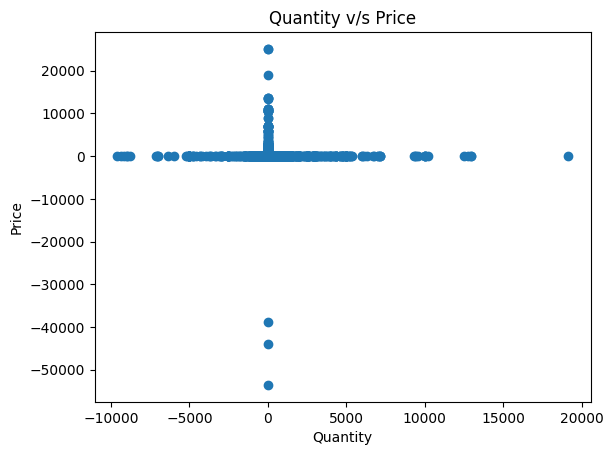

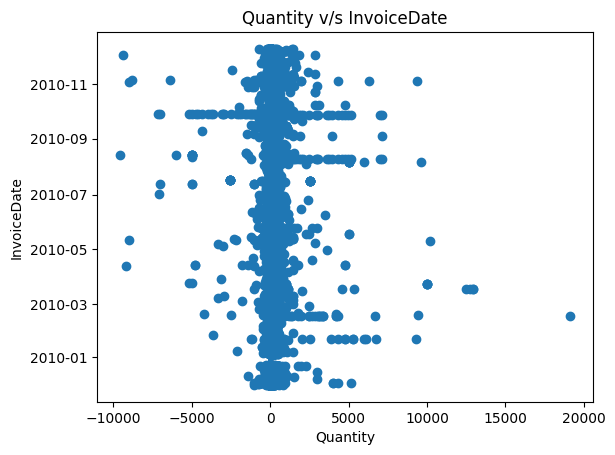

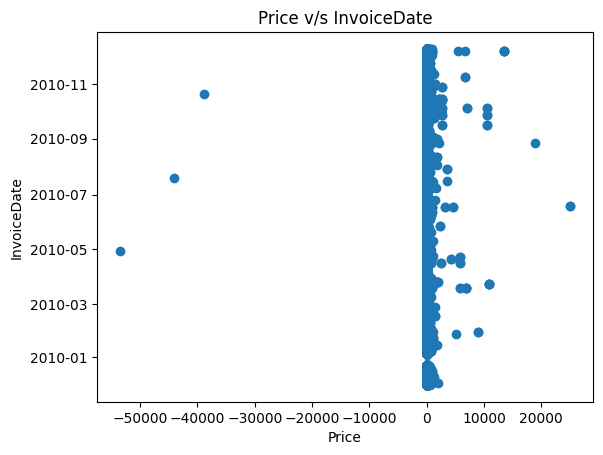

## Correlation:

## Missing Matrix:

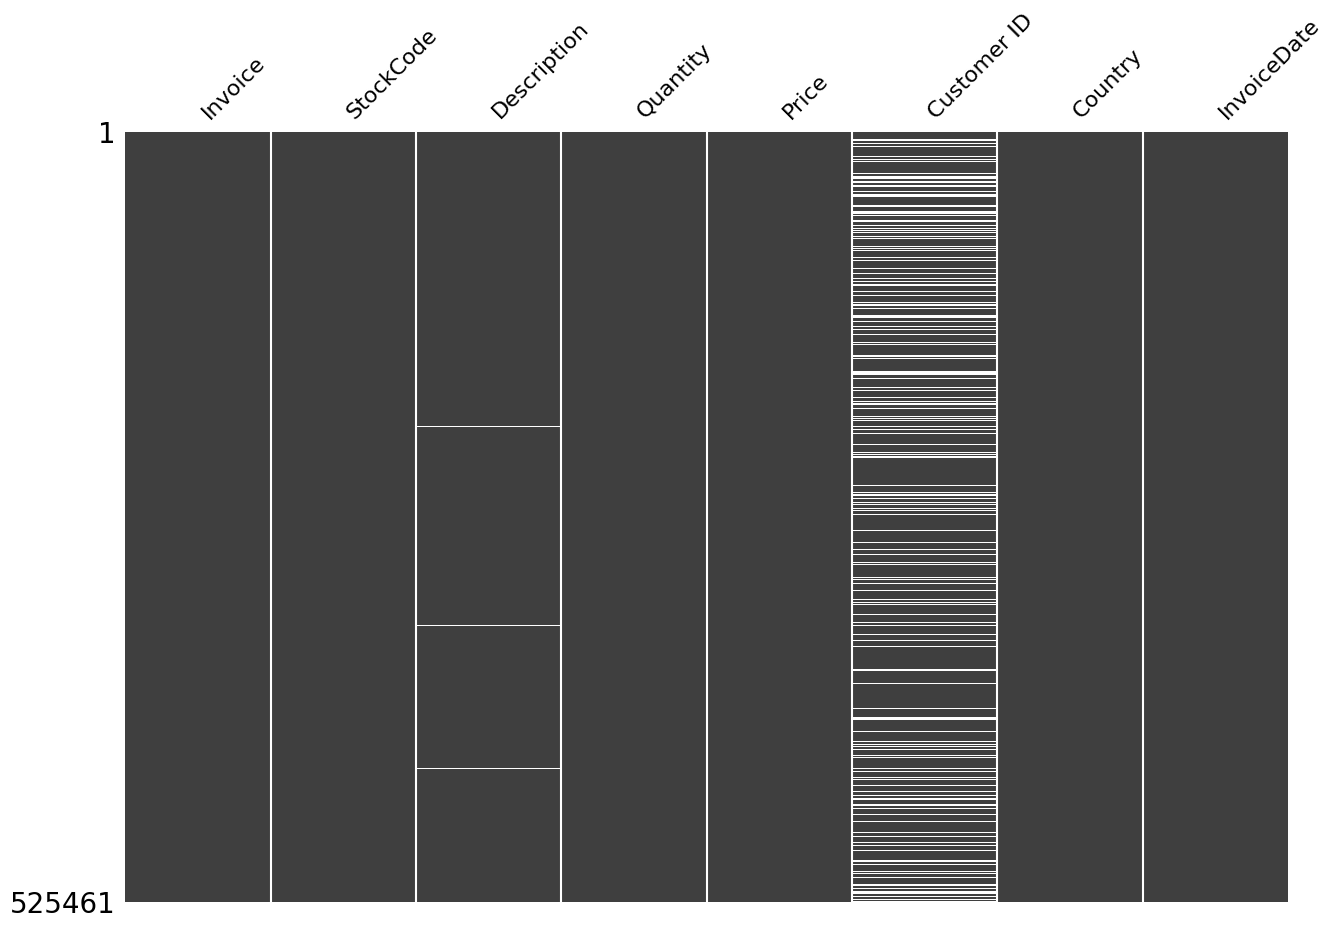

In [10]:
profile_df(df_retail)

**Respuesta:**


Se encontraron los siguientes patrones:

- **Dispersión y Outliers:** En los gráficos de dispersión (como `Quantity v/s Price`), los datos se concentran masivamente cerca del origen, pero la escala se ve distorsionada por valores extremos (outliers). Se identifican puntos con cantidades y precios significativamente altos, así como una presencia notoria de valores negativos en ambos ejes, lo que sugiere registros de devoluciones o errores de ingreso.
- **Comportamiento Temporal:** Los gráficos que involucran `InvoiceDate` muestran una actividad transaccional constante con picos de volumen. Sin embargo, se aprecian "ruidos" representados por líneas verticales de puntos que se alejan del promedio, indicando transacciones atípicas en días específicos.
- **Datos Faltantes:** La matriz de datos faltantes revela que la columna `Customer ID` tiene una cantidad considerable de valores ausentes (aproximadamente un 20% del total). El resto de las columnas críticas, como `Invoice`, `StockCode` y `Country`, parecen estar completas.

No se observan correlaciones lineales relevantes entre las variables numéricas. El mapa de calor indica valores cercanos a **0** (por ejemplo, entre `Quantity` y `Price`). Esto es esperable en datos transaccionales de retail sin procesar, donde la presencia de outliers extremos y valores negativos "aplanan" cualquier relación estadística que pudiera existir entre el volumen de compra y el precio unitario.

Los gráficos revelan que una limpieza es estrictamente necesaria debido a:

- **Valores Negativos:** Es imperativo filtrar o tratar las cantidades y precios negativos, ya que distorsionan el cálculo de ingresos totales.
- **Tratamiento de Outliers:** Para que los modelos o análisis posteriores sean representativos, se deben eliminar o truncar los valores extremos que sesgan las distribuciones.
- **Imputación o Eliminación de Nulos:** La ausencia de `Customer ID` impide realizar un seguimiento por cliente (segmentación), por lo que se debe decidir si eliminar esos registros o etiquetarlos como "Invitado/Anónimo".
- **Consistencia de Precios:** Se observan precios unitarios en cero, los cuales deben ser investigados para determinar si corresponden a promociones o errores de sistema.


### 1.2.3 Limpieza de Datos [1 pto]

Como pudo ver en las secciones anteriores, los datos presentan valores erroneos, es por esto que se le solicita que realice una función que permita limpiar el dataset. Realice esta función en base observaciones propias y considere como **imposible tener cantidades negativas** en las ventas. Investigue sobre métodos para eliminar outliers usando pandas

Una vez realizada la función, realice nuevamente el análisis exploratorio y comente las principales diferencias.

**Respuesta:**


In [ ]:
def clean_dataset(dataframe_in):
    df_clean = dataframe_in.copy()

    df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["Price"] > 0)]

    df_clean = df_clean.dropna(subset=["Customer ID", "Description"])

    z_scores_qty = np.abs(stats.zscore(df_clean["Quantity"]))
    z_scores_price = np.abs(stats.zscore(df_clean["Price"]))

    df_clean = df_clean[(z_scores_qty < 3) & (z_scores_price < 3)]
    return df_clean

## Bivariant Analysis:

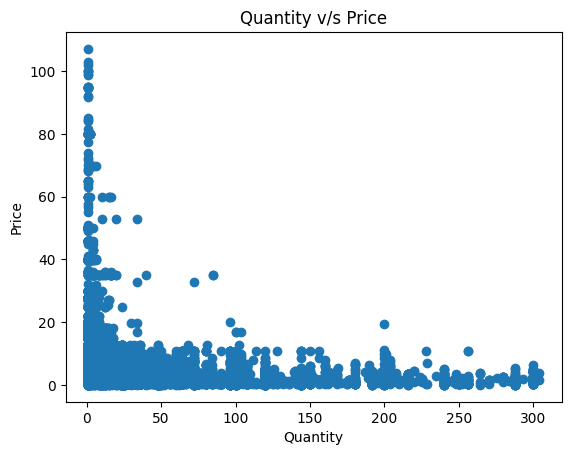

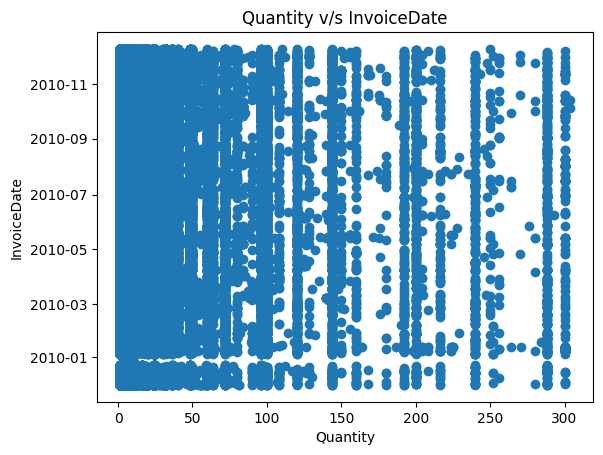

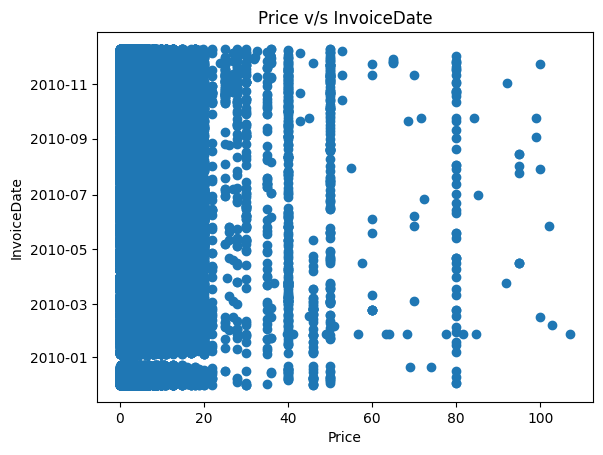

## Correlation:

## Missing Matrix:

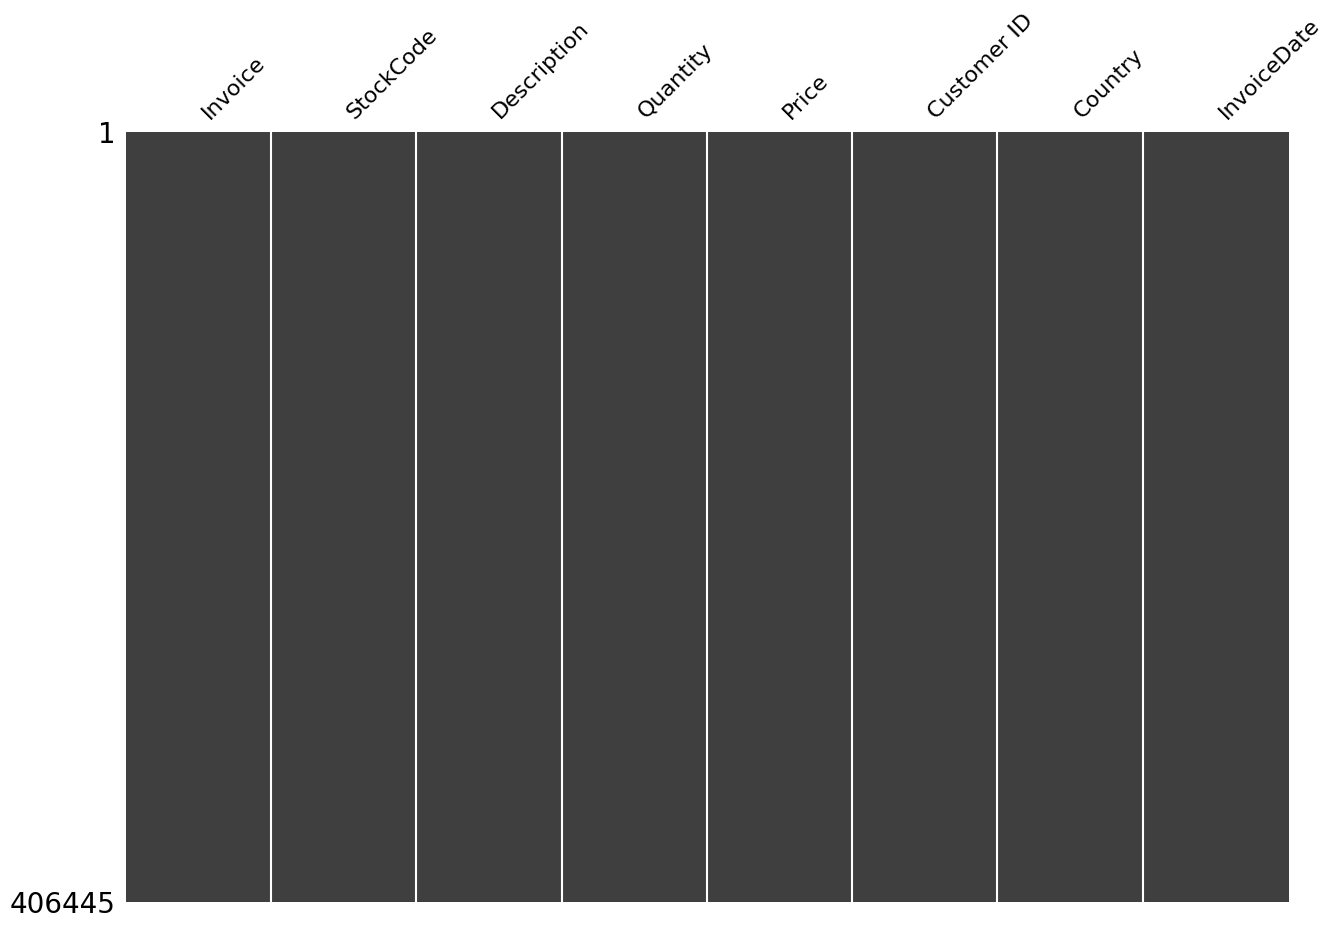

In [13]:
df_retail_clean = clean_dataset(df_retail)
profile_df(df_retail_clean)

Al realizar nuevamente el análisis exploratorio sobre el dataset limpio, las principales diferencias observadas son:

1. **Eliminación de anomalías y control de dispersión:** Los gráficos de dispersión (especialmente `Quantity v/s Price`) confirman la desaparición total de los valores negativos. Además, los ejes ahora muestran rangos mucho más acotados y reales (cantidades máximas en torno a 125 y precios bajo £30). Esto demuestra que el filtro por Z-score eliminó exitosamente los _outliers_ que deformaban la escala original.
2. **Claridad en la distribución Precio/Cantidad:** Sin el ruido de los valores atípicos, ahora se aprecia claramente una distribución en forma de "L": los grandes volúmenes de compra se concentran exclusivamente en productos de bajo precio, mientras que los artículos más caros se adquieren en cantidades mínimas.
3. **Integridad para la segmentación:** La nueva matriz de datos faltantes (Missing Matrix) evidencia que la columna `Customer ID` está 100% completa. Esto es vital, ya que asegura que todas las transacciones retenidas pueden asociarse a un cliente real para los análisis posteriores.
4. **Correlación representativa:** Aunque la matriz de correlación sigue mostrando una relación lineal débil entre `Quantity` y `Price` (-0.14), este valor ahora refleja el comportamiento genuino de los consumidores del retail, libre del fuerte sesgo que generaban las devoluciones (cantidades negativas) y las compras al por mayor atípicas.


### 1.2.4 Obtención de TOPs [0.75 ptos]


Sin considerar los comentarios realizados en la sección 1.2 , _Don Mora_ les pide obtener el **Top de 30 productos que generan más ganancias** para la tienda de retail. Deben considerar todo el registro temporal presente en el dataset y entregar la información en un gráfico de barras de los ingresos/cantidades v/s el nombre de los productos (Utilice `plotly`). ¿Los artículos más vendidos son los mismos que generan más ganancias?, Comente los resultados obtenidos.

**Resultados:**


In [ ]:
df_retail_clean["Revenue"] = df_retail_clean["Quantity"] * df_retail_clean["Price"]

df_agrupado = df_retail_clean.groupby("Description")[["Revenue", "Quantity"]].sum().reset_index()

top_30_ingresos = df_agrupado.sort_values(by="Revenue", ascending=False).head(30)
top_30_ingresos = top_30_ingresos.iloc[::-1]

fig_ingresos = px.bar(
    top_30_ingresos,
    x="Revenue",
    y="Description",
    orientation="h",
    title="Top 30 Productos con Mayores Ingresos (Ganancias)",
    labels={"Description": "Producto", "Revenue": "Ingresos Totales (£)"},
    color="Revenue",
    color_continuous_scale="Viridis",
)

fig_ingresos.update_layout(height=800)
fig_ingresos.show()

top_30_cantidades = df_agrupado.sort_values(by="Quantity", ascending=False).head(30)
top_30_cantidades = top_30_cantidades.iloc[::-1]

fig_cantidades = px.bar(
    top_30_cantidades,
    x="Quantity",
    y="Description",
    orientation="h",
    title="Top 30 Productos con Mayor Cantidad Vendida",
    labels={"Description": "Producto", "Quantity": "Unidades Vendidas"},
    color="Quantity",
    color_continuous_scale="Plasma",
)

fig_cantidades.update_layout(height=800)
fig_cantidades.show()

Al analizar el gráfico de los 30 productos con mayores ingresos, se puede concluir que **los artículos más vendidos son en general los mismos que generan la mayor cantidad de ganancias**, donde coinciden varios de los elementos en ambos rankings.

El producto que lidera indiscutidamente las ganancias y cantidades por igual es el **"WHITE HANGING HEART T-LIGHT HOLDER"**. Es el único producto que genera tantas unidades vendidas como para aumentar exponencialmente sus ingresos asociados a pesar de su precio. Sin embargo, es notorio que la mayoría de artículos vendidos son de precios bajos, pero tienen tantas ventas que son mucho más rentables que vender productos con mayor margen de ganancia individual.


### 1.2.5 Visualización del registro temporal [0,75 ptos]


El dueño del retail en su afán por saber más sobre los datos de su firma les solicita que grafiquen las ventas respecto al tiempo. Con esto les aclara que durante el día tienen muchas variaciones en sus ventas, por lo que les recomienda que consideren el registro temporal como `año-mes-día`. ¿Es posible observar datos extraños?, Comente lo que observa del gráfico.


In [ ]:
def plot_ventas(dataframe):
    df = dataframe.copy()

    if "Ganancias" not in df.columns:
        df["Ganancias"] = df["Quantity"] * df["Price"]

    df["Fecha"] = df["InvoiceDate"].dt.date

    ventas_diarias = df.groupby("Fecha")["Ganancias"].sum().reset_index()

    fig = px.line(
        ventas_diarias,
        x="Fecha",
        y="Ganancias",
        title="Evolución de las Ventas Diarias",
        labels={"Fecha": "Fecha (Año-Mes-Día)", "Ganancias": "Ingresos Totales (£)"},
    )

    fig.update_xaxes(rangeslider_visible=True)

    fig.show()


plot_ventas(df_retail_clean)

Al observar la gráfica es posible identificar que a lo largo de todo el registro temporal se observan valles recurrentes donde los ingresos caen drásticamente, llegando a cero o valores muy cercanos a cero. Este comportamiento sistemático refleja con seguridad los días inactivos de la tienda, correspondientes a los fines de semana o días en los que no se procesan transacciones. Además el gráfico evidencia un cambio de régimen en el último trimestre de 2010 (octubre a diciembre). Durante este periodo se aprecian picos puntuales muy marcados donde los ingresos superan incluso en ocasiones los 60.000 euros. Esto demuestra el fuerte impacto de la temporada de compras festivas de fin de año. Por último, en el extremo izquierdo (transición entre 2009 y 2010) y en el extremo derecho (finales de diciembre de 2010), se notan caídas abruptas y espacios en la continuidad de la línea. Esto sugiere periodos de cierre prolongado por las festividades de Navidad y Año Nuevo, o bien que la recolección de datos quedó incompleta en las fronteras de este registro temporal.


# Conclusión

Eso ha sido todo para el lab de hoy, recuerden que el laboratorio tiene un plazo de entrega de una semana. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

![Gracias Totales!](https://i.pinimg.com/originals/65/ae/27/65ae270df87c3c4adcea997e48f60852.gif "bruno")


<br>
<center>
<img src="https://i.kym-cdn.com/photos/images/original/001/194/195/b18.png" width=100 height=50 />
</center>
<br>


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=87110296-876e-426f-b91d-aaf681223468' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>
